In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd
# Load raw URLs
X_train = pd.read_csv("../data/X_train.csv")['url'].astype(str)
X_test = pd.read_csv("../data/X_test.csv")['url'].astype(str)

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

# Tokenization
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [25]:
import joblib

joblib.dump(tokenizer, "../saved_models/tokenizer.pkl")

print("Tokenizer saved successfully ✅")

Tokenizer saved successfully ✅


In [3]:
import sys
import os
import shap
import matplotlib.pyplot as plt
import joblib
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models import lstm_model

lstm = lstm_model(vocab_size, max_len)

lstm.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_split=0.2)

C:\Users\kisho\OneDrive\Documents\Projects\Phishing_url_detection\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
10099/10099 ━━━━━━━━━━━━━━━━━━━━ 1008s 99ms/step - accuracy: 0.7460 - loss: 0.5287 - val_accuracy: 0.9795 - val_loss: 0.0857
Epoch 2/5
10099/10099 ━━━━━━━━━━━━━━━━━━━━ 584s 58ms/step - accuracy: 0.9855 - loss: 0.0597 - val_accuracy: 0.9894 - val_loss: 0.0466
Epoch 3/5
10099/10099 ━━━━━━━━━━━━━━━━━━━━ 644s 64ms/step - accuracy: 0.9892 - loss: 0.0459 - val_accuracy: 0.9912 - val_loss: 0.0378
Epoch 4/5
10099/10099 ━━━━━━━━━━━━━━━━━━━━ 621s 57ms/step - accuracy: 0.9916 - loss: 0.0362 - val_accuracy: 0.9923 - val_loss: 0.0339
Epoch 5/5
10099/10099 ━━━━━━━━━━━━━━━━━━━━ 633s 58ms/step - accuracy: 0.9925 - loss: 0.0309 - val_accuracy: 0.9926 - val_loss: 0.0310


In [5]:
lstm_preds = lstm.predict(X_test_pad).ravel()

3156/3156 ━━━━━━━━━━━━━━━━━━━━ 64s 20ms/step


In [7]:
lstm.save("../saved_models/lstm_model.keras")
import joblib
import pandas as pd

# Load saved stacking model
stack = joblib.load("../saved_models/stacking_phishing_model.pkl")

# Load features
X_test_f = pd.read_csv("../data/X_test_features.csv")

# Get predictions
stack_preds = stack.predict_proba(X_test_f)[:, 1]

In [14]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Combine predictions
X_meta = np.column_stack((stack_preds, lstm_preds))  
# if transformer used:
# X_meta = np.column_stack((stack_preds, lstm_preds, transformer_preds))

meta_model = LogisticRegression()
meta_model.fit(X_meta, y_test)

final_preds = meta_model.predict(X_meta)


In [23]:
from src.evaluation import full_report

full_report(meta_model,X_meta, y_test)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     69148
           1       0.99      0.99      0.99     31839

    accuracy                           0.99    100987
   macro avg       0.99      0.99      0.99    100987
weighted avg       0.99      0.99      0.99    100987


Confusion Matrix:
[[68953   195]
 [  445 31394]]


In [24]:
import joblib

joblib.dump(meta_model, "../saved_models/hybrid_meta_model.pkl")

print("Meta model saved successfully ✅")

Meta model saved successfully ✅


C:\Users\kisho\OneDrive\Documents\Projects\Phishing_url_detection\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Enter a URL to test:  http://secure-login-paypal.xyz



URL: http://secure-login-paypal.xyz

Lexical Features:
url_length: 30
num_dots: 1
num_hyphens: 2
num_digits: 0
num_special_chars: 6

Structural Features:
has_https: 0
domain_length: 23
path_length: 0
has_ip: 0
subdomain_count: 0
has_at_symbol: 0
double_slash_redirect: 0
long_url: 0
has_suspicious_tld: 1
has_suspicious_ext: 0
brand_in_domain: 1
brand_in_path: 0

Semantic Features:
has_login: 1
has_verify: 0
has_secure: 1
has_account: 0
has_update: 0
has_bank: 0
has_confirm: 0
has_signin: 0
has_paypal: 1
has_ebay: 0
has_free: 0
has_bonus: 0

Advanced Security Features:
trusted_domain: 0
brand_mismatch: 0
has_shortener: 0
keyword_count: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step

Prediction Result:
🚨 Phishing URL detected
Final Probability: 0.9988
(Stacking: 0.9956 | LSTM: 0.9998)

Generating SHAP explanation...


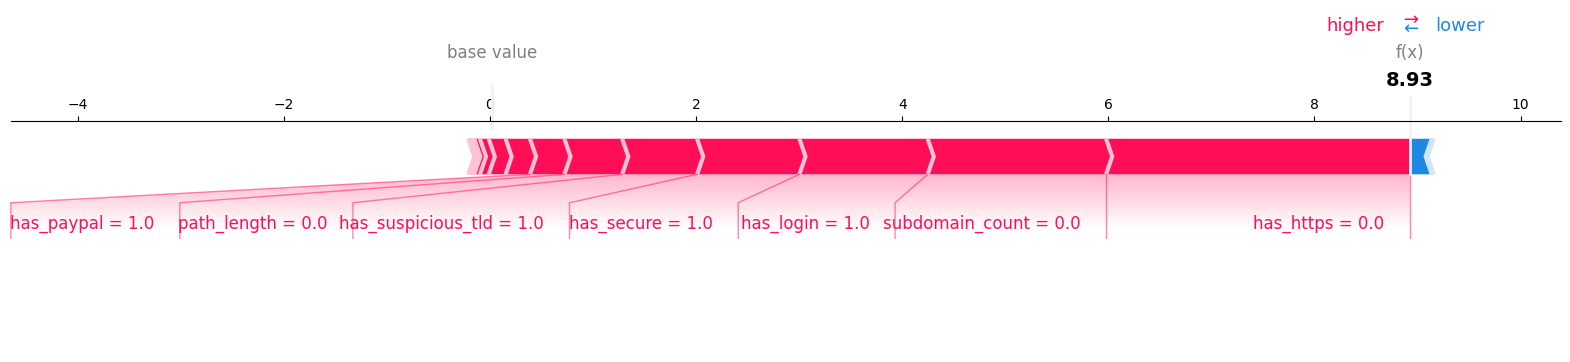

In [3]:
import sys
import os
import shap
import matplotlib.pyplot as plt
import joblib
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.feature_engineering import extract_single_url_features

import pandas as pd
import numpy as np
import joblib
import shap

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# 🔹 Load Everything
# ==============================

stack = joblib.load("../saved_models/stacking_phishing_model.pkl")
meta_model = joblib.load("../saved_models/hybrid_meta_model.pkl")
tokenizer = joblib.load("../saved_models/tokenizer.pkl")
lstm = load_model("../saved_models/lstm_model.keras")

feature_columns = joblib.load("../saved_models/feature_columns.pkl")

MAX_LEN = 100

# ==============================
# 5️⃣ Test with Input URL
# ==============================

sample_url = input("\nEnter a URL to test: ").strip().lower()

# ------------------------------
# 🔹 1. ML → Stacking
# ------------------------------

features = extract_single_url_features(sample_url)

features_df = pd.DataFrame([features])
features_df = features_df.reindex(columns=feature_columns, fill_value=0)

stack_prob = stack.predict_proba(features_df)[0][1]

# ------------------------------
# 🔹 2. LSTM
# ------------------------------

seq = tokenizer.texts_to_sequences([sample_url])
pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

lstm_prob = lstm.predict(pad)[0][0]

# ------------------------------
# 🔹 3. Hybrid Meta Model
# ------------------------------

X_meta = np.array([[stack_prob, lstm_prob]])

final_pred = meta_model.predict(X_meta)[0]
final_prob = meta_model.predict_proba(X_meta)[0][1]

# ------------------------------
# 🔹 Output
# ------------------------------

print("\nPrediction Result:")

if final_pred == 1:
    print("🚨 Phishing URL detected")
else:
    print("✅ Legitimate URL")

print(f"Final Probability: {final_prob:.4f}")
print(f"(Stacking: {stack_prob:.4f} | LSTM: {lstm_prob:.4f})")

# ==============================
# 🔥 SHAP Explanation (ML Part)
# ==============================

print("\nGenerating SHAP explanation...")

xgb_model = stack.named_estimators_["xgb"]
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(features_df)

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    features_df.iloc[0],
    matplotlib=True
)